# EDA 1

## first view at the data

In [1]:
import pandas as pd

# Load train data
train = pd.read_csv("../dataset/train.csv")

# Basic info
print("Shape of train data:", train.shape)
train.info()

# First few rows
train.head()


Shape of train data: (75000, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        75000 non-null  int64  
 1   catalog_content  75000 non-null  object 
 2   image_link       75000 non-null  object 
 3   price            75000 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.3+ MB


,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


In [4]:
train.isnull().sum().sort_values(ascending=False)


sample_id          0
catalog_content    0
image_link         0
price              0
dtype: int64

In [5]:

# Load test data
test = pd.read_csv("../dataset/test.csv")

# Basic info
print("Shape of test data:", test.shape)
test.info()

# First few rows
test.head()


Shape of test data: (75000, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   sample_id        75000 non-null  int64 
 1   catalog_content  75000 non-null  object
 2   image_link       75000 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


,sample_id,catalog_content,image_link
0,100179,Item Name: Rani 14-Spice Eshamaya's Mango Chut...,https://m.media-amazon.com/images/I/71hoAn78AW...
1,245611,Item Name: Natural MILK TEA Flavoring extract ...,https://m.media-amazon.com/images/I/61ex8NHCIj...
2,146263,Item Name: Honey Filled Hard Candy - Bulk Pack...,https://m.media-amazon.com/images/I/61KCM61J8e...
3,95658,Item Name: Vlasic Snack'mm's Kosher Dill 16 Oz...,https://m.media-amazon.com/images/I/51Ex6uOH7y...
4,36806,"Item Name: McCormick Culinary Vanilla Extract,...",https://m.media-amazon.com/images/I/71QYlrOMoS...


In [7]:
test.isnull().sum().sort_values(ascending=False)

sample_id          0
catalog_content    0
image_link         0
dtype: int64

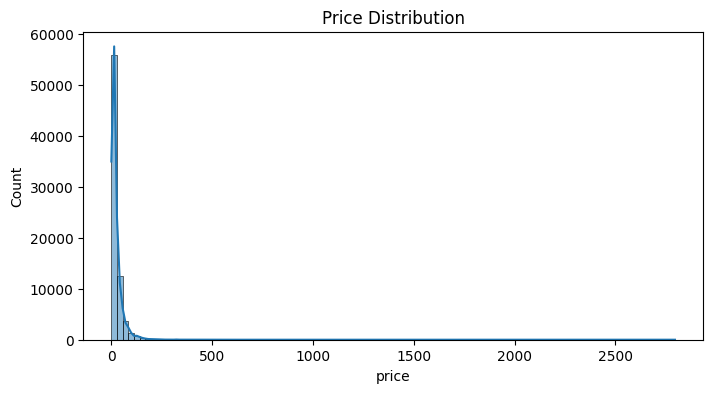

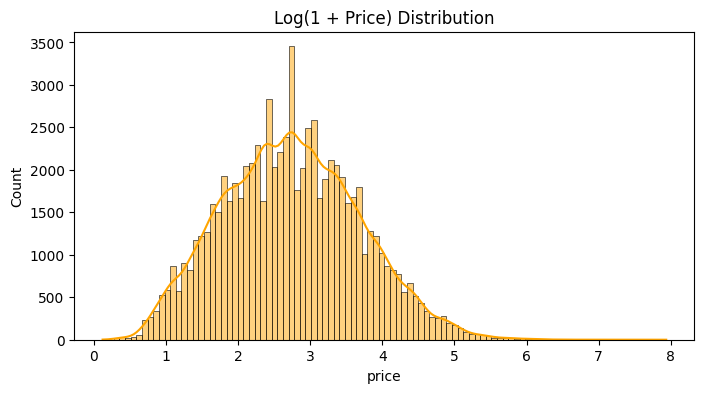

count    75000.000000
mean        23.647654
std         33.376932
min          0.130000
1%           1.320000
5%           2.440000
25%          6.795000
50%         14.000000
75%         28.625000
95%         75.711000
99%        145.250300
max       2796.000000
Name: price, dtype: float64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8,4))
sns.histplot(train['price'], bins=100, kde=True)
plt.title("Price Distribution")
plt.show()

# Log-transformed view
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(train['price']), bins=100, kde=True, color='orange')
plt.title("Log(1 + Price) Distribution")
plt.show()

print(train['price'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))


           text_len    word_count
count  75000.000000  75000.000000
mean     908.886547    147.851693
std      852.896151    137.068731
min       32.000000      7.000000
25%      251.000000     42.000000
50%      643.000000    104.000000
75%     1280.000000    208.000000
max     7894.000000   1333.000000


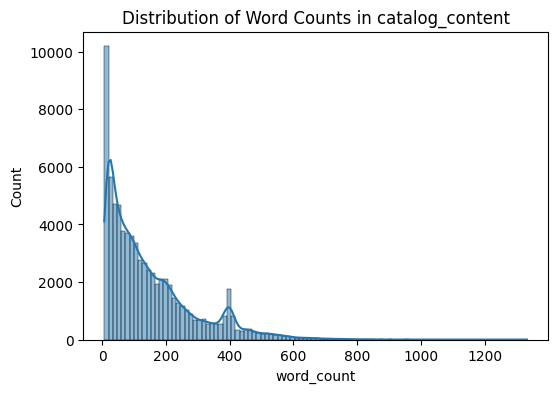

In [7]:
train['text_len'] = train['catalog_content'].fillna("").apply(len)
train['word_count'] = train['catalog_content'].fillna("").apply(lambda x: len(x.split()))

print(train[['text_len', 'word_count']].describe())

plt.figure(figsize=(6,4))
sns.histplot(train['word_count'], bins=100, kde=True)
plt.title("Distribution of Word Counts in catalog_content")
plt.show()
